# MODELIZACION PARA NO SUPERVISADO

## IMPORTAR PAQUETES

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics import calinski_harabasz_score
from sklearn.metrics import davies_bouldin_score

from sklearn.model_selection import GridSearchCV

#Autocompletar rápido
%config IPCompleter.greedy=True

#Desactivar la notación científica
pd.options.display.float_format = '{:.2f}'.format

#Desactivar los warnings
import warnings
warnings.filterwarnings("ignore")

## IMPORTAR LOS DATOS

Sustituir la ruta del proyecto.

In [2]:
ruta_proyecto = 'C:/Users/vifra/vidal cientifico de datos/Portafolio ML/Proyecto leadscoring/00_PROYECTO_LEADSCORING/'

Nombres de los ficheros de datos.

In [5]:
nombre_df = 'df_tablon.pickle'


Cargar los datos.

In [6]:
df = pd.read_pickle(ruta_proyecto + '/02_Datos/03_Trabajo/' + nombre_df)


In [7]:
df

,origen_API,origen_Landing Page Submission,origen_Lead Add Form,origen_OTROS,fuente_Chat,fuente_Direct Traffic,fuente_Google,fuente_OTROS,fuente_Organic Search,fuente_Reference,...,ocupacion_Unemployed,ocupacion_Working Professional,descarga_lm_No,descarga_lm_Yes,visitas_total_mms,tiempo_en_site_total_mms,paginas_vistas_visita_mms,score_actividad_mms,score_perfil_mms,compra
id,,,,,,,,,,,,,,,,,,,,,
660737,1.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,...,1.00,0.00,1.00,0.00,0.00,0.00,0.00,0.73,0.44,0
660728,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,...,1.00,0.00,1.00,0.00,0.10,0.30,0.16,0.73,0.44,0
660727,0.00,1.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,1.00,0.04,0.67,0.12,0.64,1.00,1
660719,0.00,1.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,...,1.00,0.00,1.00,0.00,0.02,0.13,0.06,0.55,0.67,0
660681,0.00,1.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,...,1.00,0.00,1.00,0.00,0.04,0.63,0.06,0.73,0.78,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
579564,0.00,1.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,...,1.00,0.00,1.00,0.00,0.16,0.81,0.17,0.73,0.67,1
579546,0.00,1.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,...,1.00,0.00,0.00,1.00,0.04,0.10,0.12,0.64,0.89,0
579545,0.00,1.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,...,1.00,0.00,0.00,1.00,0.04,0.09,0.12,0.55,1.00,0


## MODELIZAR

### Crear el espacio de soluciones

In [8]:
min_k = 3
max_k = 7

soluciones = list(range(min_k,max_k))

### Crear listas para guardar la salida de cada metrica

In [9]:
codo = []
silueta = []
calins = []
davies = []

### Analizar el espacio de soluciones

In [11]:
for solucion in soluciones:
    
    #Instanciar
    cluster = KMeans(n_clusters = solucion, n_init=10)
    
    #Entrenar
    cluster.fit(df)
    
    #Recoger las métricas
    codo.append(cluster.inertia_)
    silueta.append(silhouette_score(df, cluster.labels_))
    calins.append(calinski_harabasz_score(df, cluster.labels_))
    davies.append(davies_bouldin_score(df, cluster.labels_))

### Identificar la mejor solucion

#### Analizar las métricas

In [12]:
metricas = pd.DataFrame({'Solucion':soluciones,
              'Codo': codo,
              'Silueta':silueta,
              'Calins':calins,           
              'Davies':davies}).set_index('Solucion')

metricas

,Codo,Silueta,Calins,Davies
Solucion,,,,
3,13781.72,0.19,1043.04,2.07
4,12984.69,0.20,841.65,1.86
5,12387.81,0.17,722.60,2.12
6,11914.74,0.15,641.16,2.32


#### Analizar los graficos

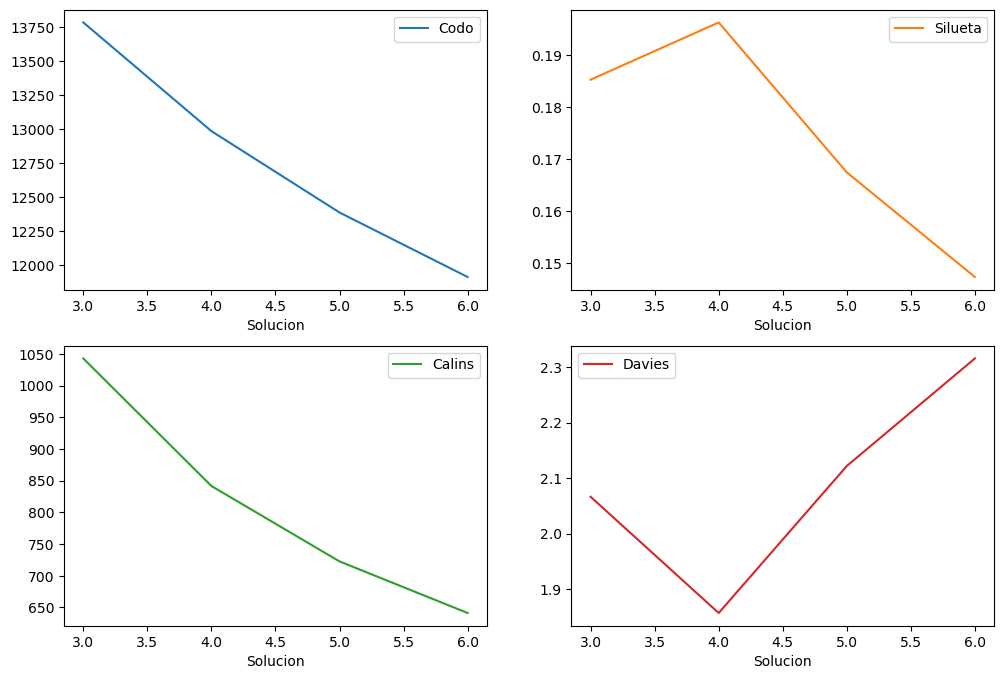

In [13]:
metricas.plot(subplots = True, figsize = (12,8), layout = (2,2), sharex = False);

### Segmentacion final con la mejor solucion

In [45]:
mejor_solucion = 6

#Instanciar
cluster = KMeans(n_clusters = mejor_solucion, n_init=10)
    
#Entrenar
cluster.fit(df)

KMeans(n_clusters=6, n_init=10)

## EVALUAR

Comprobar que los perfiles obtenidos en entrenamiento son similares a los objetidos al predecir sobre validación.

### Calcular el segmento en entrenamiento y en validacion

In [46]:
df['segmento'] = cluster.predict(df)

In [47]:
df['segmento']

id
660737    2
660728    2
660727    1
660719    5
660681    5
         ..
579564    5
579546    1
579545    1
579538    0
579533    1
Name: segmento, Length: 5075, dtype: int32

### Comparar los perfiles

#### Calcular los perfiles

#### Comparar los perfiles

## PERFILAR LOS SEGMENTOS

In [48]:
df.groupby('segmento').mean().T \
    .style.highlight_max(color = 'lightgreen', axis = 1) \
    .highlight_min(color = 'red', axis = 1)

segmento,0,1,2,3,4,5
origen_API,0.065603,0.003922,0.978245,0.255495,0.149425,0.017958
origen_Landing Page Submission,0.930851,0.996078,0.001450,0.054945,0.850575,0.980151
origen_Lead Add Form,0.000000,0.000000,0.000725,0.673077,0.000000,0.000000
origen_OTROS,0.003546,0.000000,0.019579,0.016484,0.000000,0.001890
fuente_Chat,0.000000,0.000000,0.171864,0.071429,0.103448,0.000000
fuente_Direct Traffic,0.164894,1.000000,0.047861,0.046703,0.000000,0.196597
fuente_Google,0.762411,0.000000,0.500363,0.129121,0.000000,0.747637
fuente_OTROS,0.010638,0.000000,0.064540,0.057692,0.048276,0.011342
fuente_Organic Search,0.062057,0.000000,0.215373,0.063187,0.848276,0.044423
fuente_Reference,0.000000,0.000000,0.000000,0.631868,0.000000,0.000000
